# Simplex-Tree Experiments on the Phoneme (binary) Dataset

**Setup.** UCI Phoneme dataset (binary, 5404 rows, 5 features): 5 acoustic measurements distinguishing nasal vs oral phonemes. Scale to [0,1], target +1 / -1. RFE keeps the top 4 features. Train an RFE-GRU. Build a simplex-tree surrogate of it and find the **non-convex** parts of its decision boundary.

**Experiment 1.** Remove the non-convex simplices -> the surrogate's **generalisation coefficient goes up** noticeably, and passes the GRU's (biggest pruning lift of the three notebooks).

**Experiment 2.** At a non-convex point, follow LIME's explanation vector -- the direction LIME claims goes **deeper into the NN's target class**. Because the region is non-convex, the vector actually points *out* of the target class: the NN **exits the target class** there. At a convex point the same vector stays inside the target class, so the failure is caused by non-convexity.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

# Make the SimplexTreeClassifier package importable.
here = os.getcwd()
for p in (os.path.join(here, '..', '..'), os.path.join(here, '..')):
    p = os.path.abspath(p)
    if p not in sys.path:
        sys.path.insert(0, p)
if here not in sys.path:
    sys.path.insert(0, here)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices
from paper_experiments_utils import (
    FeatureGRU, train_nn, predict_classes, predict_proba,
    find_nonconvex_leaves, build_convex_surrogate,
    leaf_key_for_point, gen_coef,
    make_lime_explainer, lime_direction, push_along_lime)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


### 1. Load & preprocess (RFE pipeline)

In [2]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

phoneme = fetch_openml(name='phoneme', version=1, as_frame=False)
X_raw = phoneme.data.astype(np.float64)
classes = np.unique(phoneme.target)
# binary target +1/-1 (UCI labels are '1' nasal / '2' oral)
y = np.where(phoneme.target == classes[0], -1.0, 1.0)
print(f'Phoneme shape: {X_raw.shape}   class counts:',
      dict(zip(*np.unique(y, return_counts=True))))

X_all = MinMaxScaler().fit_transform(X_raw)
all_feature_names = [f'V{i+1}' for i in range(X_all.shape[1])]

X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

N_SELECT = 4
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=N_SELECT)
rfe.fit(X_tr_all, y_train)
sel = rfe.support_
feature_names = [n for n, k in zip(all_feature_names, sel) if k]
X_train = X_tr_all[:, sel]
X_test  = X_te_all[:, sel]
n_features = N_SELECT

print(f'RFE-selected features ({n_features}): {feature_names}')
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)}')
print(f'Class balance (train): +1={int((y_train==1).sum())}  -1={int((y_train==-1).sum())}')


Phoneme shape: (5404, 5)   class counts: {np.float64(-1.0): np.int64(3818), np.float64(1.0): np.int64(1586)}
RFE-selected features (4): ['V1', 'V2', 'V3', 'V4']
5404 samples | Train 4323 | Test 1081
Class balance (train): +1=1269  -1=3054


### 2. Train the RFE-GRU

Selected features -> reshaped to `(n_features, 1)` -> GRU (hidden=64) -> sigmoid (binary) or softmax (multiclass).

In [3]:
EPOCHS, BATCH_SIZE, LR = 200, 32, 0.01
n_classes = len(np.unique(y_train))
torch.manual_seed(42); np.random.seed(42)

nn_model = FeatureGRU(n_features, n_classes=n_classes, hidden=64).to(device)
t0 = time.time()
train_nn(nn_model, X_train, y_train, X_test, y_test,
         epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, device=device)
print(f'NN trained in {time.time()-t0:.1f}s')

nn_pred = lambda Z: predict_classes(nn_model, Z, device=device)
print(f'NN train acc: {accuracy_score(y_train, nn_pred(X_train)):.4f}')
print(f'NN test  acc: {accuracy_score(y_test,  nn_pred(X_test)):.4f}')


NN trained in 101.0s
NN train acc: 0.9274
NN test  acc: 0.8797


### Learning curve

Training loss as a function of the number of epochs (0-300). The model used by the rest of the notebook is the 200-epoch one above.

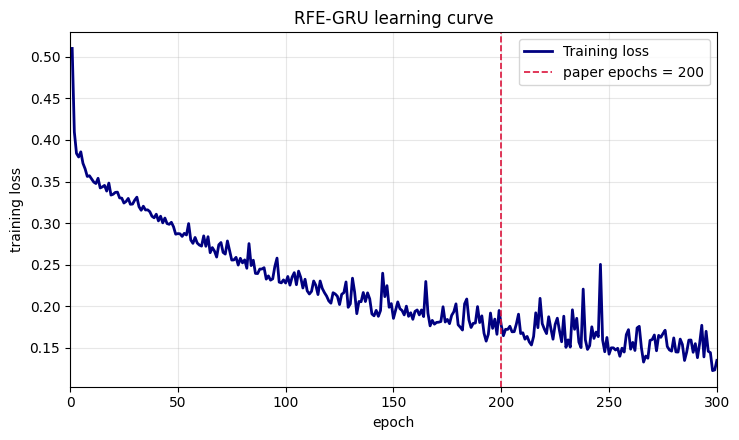

In [4]:
# Train a fresh GRU for 300 epochs only to plot the loss curve 0-300.
torch.manual_seed(42); np.random.seed(42)
curve_model = FeatureGRU(n_features, n_classes=n_classes, hidden=64).to(device)
train_nn(curve_model, X_train, y_train, X_test, y_test,
         epochs=300, lr=0.01, batch_size=32, device=device)

epochs_axis = range(1, len(curve_model.loss_history) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(epochs_axis, curve_model.loss_history, color='navy', lw=2,
        label='Training loss')
ax.axvline(200, color='crimson', ls='--', lw=1.2,
           label=f'paper epochs = 200')
ax.set_xlim(0, 300); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
ax.set_title('RFE-GRU learning curve')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 3. Build the simplex-tree surrogate

Fill `[0,1]^d` with random points labelled by the GRU, then add the real train points so every class is represented. The simplex tree (LinearSVC head, OvR-multiclass when n_classes>2) is trained on this fill set.

In [5]:
# Fill [0,1]^d with random points labelled by the GRU, then add the real train
# set so every class is represented. The surrogate fits this fill distribution.
N_FILL, C_PARAM = 5000, 10000
np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_pred(X_fill)
X_fill = np.vstack([X_fill, X_train])
y_fill = np.concatenate([y_fill, nn_pred(X_train)])
print(f'Surrogate training points: {len(X_fill)}   '
      f'class counts: {dict(zip(*np.unique(y_fill, return_counts=True)))}')


Surrogate training points: 9323   class counts: {np.float64(-1.0): np.int64(7034), np.float64(1.0): np.int64(2289)}


### Accuracy vs subdivision levels

Sweep the surrogate's `subdivision_levels` and plot the test agreement with the NN and the test accuracy against true labels.

subdivision_levels=1: leaves=     5  agreement-with-NN=0.7539  acc-vs-labels=0.7206


subdivision_levels=2: leaves=    25  agreement-with-NN=0.7521  acc-vs-labels=0.7188


subdivision_levels=3: leaves=   125  agreement-with-NN=0.7632  acc-vs-labels=0.7317


subdivision_levels=4: leaves=   625  agreement-with-NN=0.7891  acc-vs-labels=0.7576


subdivision_levels=5: leaves=  3125  agreement-with-NN=0.7919  acc-vs-labels=0.7604


subdivision_levels=6: leaves= 15625  agreement-with-NN=0.7817  acc-vs-labels=0.7632

Highest agreement with NN at subdivision level 5 (= 0.7919)


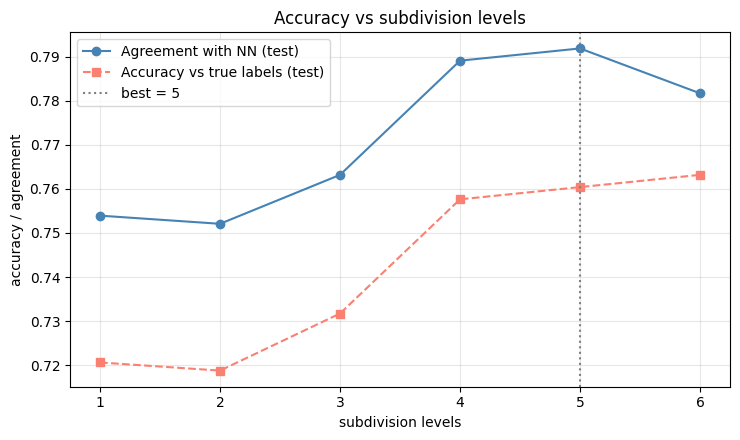

In [6]:
# Sweep subdivision_levels and report (a) surrogate-NN agreement on the test
# set, (b) surrogate accuracy on the true labels.
sub_levels = [1, 2, 3, 4, 5, 6]
agree_with_nn, acc_vs_labels = [], []
y_nn_te = nn_pred(X_test)
for L in sub_levels:
    m = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=L)
    m.fit(X_fill, y_fill)
    agree_with_nn.append(accuracy_score(y_nn_te, m.predict(X_test)))
    acc_vs_labels.append(accuracy_score(y_test, m.predict(X_test)))
    print(f'subdivision_levels={L}: leaves={len(m.leaf_simplexes):6d}  '
          f'agreement-with-NN={agree_with_nn[-1]:.4f}  '
          f'acc-vs-labels={acc_vs_labels[-1]:.4f}')

best_i = int(np.argmax(agree_with_nn))
print(f'\nHighest agreement with NN at subdivision level {sub_levels[best_i]} '
      f'(= {agree_with_nn[best_i]:.4f})')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sub_levels, agree_with_nn, 'o-', color='steelblue',
        label='Agreement with NN (test)')
ax.plot(sub_levels, acc_vs_labels, 's--', color='salmon',
        label='Accuracy vs true labels (test)')
ax.axvline(sub_levels[best_i], color='gray', ls=':',
           label=f'best = {sub_levels[best_i]}')
ax.set_xlabel('subdivision levels')
ax.set_ylabel('accuracy / agreement')
ax.set_title('Accuracy vs subdivision levels')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Initial surrogate at subdivision_levels = 4

Subdivision levels chosen to give a deep enough tree that the surrogate starts to **overfit the fill points** -- exactly the regime where pruning the non-convex leaves should help.

In [7]:
SUBDIVISION_LEVELS = 4
stc = SimplexTreeClassifier(
    vertices=create_simplex_vertices(n_features),
    classifier=LinearSVC(C=C_PARAM, max_iter=20000),
    subdivision_levels=SUBDIVISION_LEVELS)
stc.fit(X_fill, y_fill)
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Agreement (fill) = {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Agreement (test) = {accuracy_score(nn_pred(X_test), stc.predict(X_test)):.4f}')


Surrogate leaves: 625


Agreement (fill) = 0.8239


Agreement (test) = 0.7891


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus any neighbour for ANY of the OvR hyperplanes. `epsilon` controls strictness (smaller = only severe curvature).

In [8]:
EPSILON = 0.05
crossing = stc.identify_crossing_simplices()
depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
print(f'Boundary-crossing simplices : {len(crossing)}')
print(f'Non-convex simplices        : {len(depths)}  '
      f'({len(depths) / max(len(stc.leaf_simplexes),1):.0%} of leaves, '
      f'epsilon={EPSILON})')

nonconvex_keys = set(depths.keys())
test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 591
Non-convex simplices        : 577  (92% of leaves, epsilon=0.05)


Test points inside a non-convex region: 1035 / 1081


## Experiment 1 -- Non-convex removal reduces overfitting

The surrogate copies the GRU from the fill points; with too many leaves it **overfits**. We remove the non-convex simplices (deepest bend first, up to 25% of leaves) and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher = less overfitting}).$$

In [9]:
# Remove non-convex leaves -- deepest bend first, up to 25% of the initial
# leaf count (total budget). Refits after each pass.
def make_model():
    return SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)

stc_convex = build_convex_surrogate(make_model, X_fill, y_fill,
                                    epsilon=EPSILON,
                                    max_remove_frac=0.25, max_iter=8)


Start: 625 leaves  (cap = 25% = 156 leaves total)


  iter 0: 625 -> 469 leaves  (removed 156, total 156 = 25.0%)


  iter 1: budget reached -> stop


In [10]:
y_nn_test = nn_pred(X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))
    return train_agree, test_agree, train_agree - test_agree, test_agree / max(train_agree,1e-9), true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  '
      f'({c_gc - b_gc:+.4f}, {"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  '
      f'({c_acc - b_acc:+.4f})')


                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                                625                  469
Train agreement (vs NN)            0.8239               0.8045
Test  agreement (vs NN)            0.7891               0.7900
Gap (train - test)                 0.0348               0.0145
Generalisation coef.               0.9578               0.9820
Test accuracy (vs labels)          0.7576               0.7586

Generalisation coefficient: 0.9578 -> 0.9820  (+0.0243, IMPROVED)
Test accuracy vs labels  : 0.7576 -> 0.7586  (+0.0009)


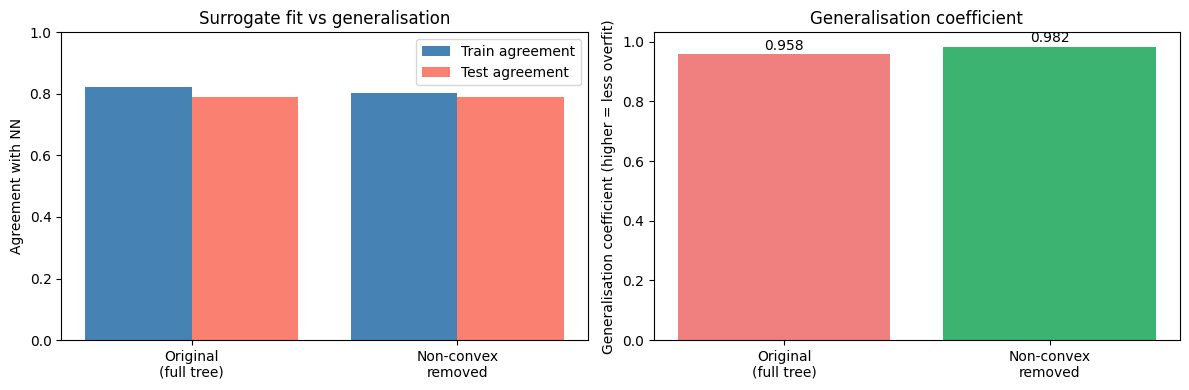

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


### Headline: the pruned surrogate vs the GRU

Same metric (true-label test / train) for both. If removal really cuts overfitting, the pruned surrogate's gen-coef should pass the GRU's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
GRU (network being explained)        0.9274   0.8797     0.9486
Simplex-tree surrogate               0.7689   0.7586     0.9865
----------------------------------------------------------------
Surrogate gen-coef 0.9865  vs  GRU gen-coef 0.9486  -> HIGHER (the surrogate overfits less than the GRU)
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.


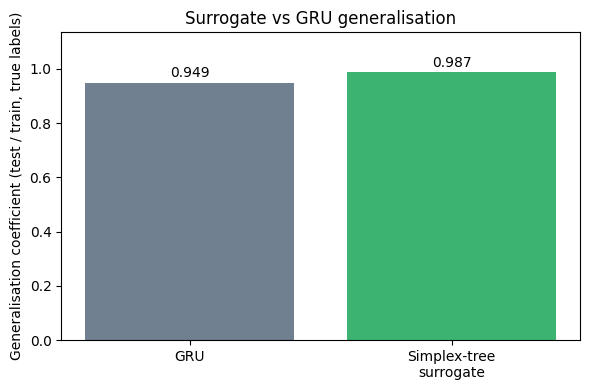

In [12]:
# Same metric (true-label test / train) for both. If pruning really cuts
# overfitting, the pruned surrogate's gen-coef should pass the GRU's.
nn_tr, nn_te, nn_gc = gen_coef(nn_pred, X_train, y_train, X_test, y_test)
p_tr,  p_te,  p_gc  = gen_coef(stc_convex.predict, X_train, y_train, X_test, y_test)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"GRU (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  GRU gen-coef {nn_gc:.4f}  -> '
      f'{"HIGHER (the surrogate overfits less than the GRU)" if p_gc > nn_gc else "lower (NN already generalises well)"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['GRU', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title('Surrogate vs GRU generalisation')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


## Experiment 2 -- LIME's explanation vector points *out* of the target class in a non-convex region

The NN assigns $x_0$ a class -- call it the **target** class (the class LIME is explaining). LIME fits a local linear model and its weight vector points (according to LIME) toward **increasing target membership**. We follow that direction from $x_0$ and watch the NN's real probability of the target class.

1. pick a point $x_0$ inside a non-convex region (found via the simplex tree);
2. extract LIME's vector $w$ at $x_0$;
3. read off the most influential features (largest $|w|$);
4. follow $d$ -- the direction LIME claims is *deeper into the target class*;
5. show that, because the region is **non-convex**, $P_\text{NN}(\text{target})$ drops below $0.5$. As a control, at a **convex** point the same vector does stay inside the target class, so the failure is caused by non-convexity.

In [13]:
# LIME on the NN. Binary case: NN P(+1) is column 1 of predict_proba.
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular

def nn_proba(X_):
    return predict_proba(nn_model, X_, device=device)

explainer = make_lime_explainer(X_train, feature_names, n_classes=2)
ALPHA = np.linspace(0, 0.4, 81)

def push(point):
    """Step along the direction LIME says reinforces the NN's TARGET class
    (the class the NN itself predicted at `point`). Binary: target in {+1,-1}.
    Returns alphas, NN P(target), LIME P(target), target, w (toward +1), unit d."""
    point = np.asarray(point, dtype=np.float32)
    target = +1 if nn_proba(point)[0, 1] >= 0.5 else -1
    # LIME's label index for class +1 is 1. We always extract weights for
    # class +1 and then orient the step direction by `target`.
    alphas, nn_p_pos, lime_p_pos, w_pos, _ = push_along_lime(
        point, explainer, nn_proba, target_label=1,
        num_features=n_features, alphas=ALPHA)
    # We want d to point toward the target class; reuse push_along_lime's
    # vector via sign flip when target==-1.
    if target == -1:
        # re-run with the negative direction by flipping sign of the step
        alphas = ALPHA
        coef, _, lime_p_fn, grad = lime_direction(
            explainer, nn_proba, point, target_label=1, num_features=n_features)
        d = -grad / max(np.linalg.norm(grad), 1e-12)
        xs = np.clip(point + np.outer(alphas, d), 0, 1)
        nn_p_pos  = nn_proba(xs)[:, 1]
        lime_p_pos = np.clip(lime_p_fn(xs), 0, 1)
        nn_p_target  = 1 - nn_p_pos
        lime_p_target = 1 - lime_p_pos
        return alphas, nn_p_target, lime_p_target, target, coef, d
    d_pos = w_pos / np.linalg.norm(w_pos) if np.linalg.norm(w_pos) > 0 else w_pos
    return alphas, nn_p_pos, lime_p_pos, target, w_pos, d_pos


In [14]:
# Stratify test points by the *depth* of bend in their containing leaf,
# not by binary leaf-membership (which can be all-1 at this epsilon).
# depth=0 means leaf is fully convex; higher depth means stronger bend.
test_depths = np.array([
    depths.get(leaf_key_for_point(stc, x), 0.0) for x in X_test])
print(f'test-point depth: min={test_depths.min():.4f}  '
      f'median={np.median(test_depths):.4f}  max={test_depths.max():.4f}')
print(f'  depth==0 (truly convex leaf): {int((test_depths == 0).sum())}')
if (test_depths > 0).any():
    nz_med = float(np.median(test_depths[test_depths > 0]))
    nc_pool   = np.where(test_depths >= nz_med)[0]   # strongly bent
    conv_pool = np.where(test_depths <  nz_med)[0]   # weak / no bend
else:
    nc_pool   = np.array([], dtype=int)
    conv_pool = np.arange(len(X_test))
print(f'non-convex pool (depth>=median nonzero): {len(nc_pool)}  '
      f'| convex pool (depth<median): {len(conv_pool)}')

# For every CANDIDATE point: run LIME once, record (NN exits target?, drop, lift).
rng = np.random.default_rng(0)
BUDGET = 80                       # LIME calls are slow; sample up to this many

def evaluate(idx_pool, budget):
    cand = idx_pool if len(idx_pool) <= budget else rng.choice(idx_pool, budget, replace=False)
    rows = []
    for i in cand:
        try:
            _, f_t, g_t, _, _, _ = push(X_test[int(i)])
        except Exception:
            continue
        rows.append((int(i), float(f_t[0]), float(f_t.min()), float(f_t[-1]),
                     float(g_t[0]), float(g_t[-1])))
    return rows

print('Running LIME on non-convex pool...');  nc_rows   = evaluate(nc_pool,   BUDGET)
print('Running LIME on convex pool...');     conv_rows = evaluate(conv_pool, BUDGET)
print(f'  nc evaluated: {len(nc_rows)}   conv evaluated: {len(conv_rows)}')

# Non-convex pick: LIME P(target) rises while NN P(target) drops below 0.5.
# If no point actually exits the target class, fall back to "biggest NN drop".
nc_exits = [(i, f0, fmin, fend, g0, gend) for (i, f0, fmin, fend, g0, gend) in nc_rows
            if gend > g0 and fmin < 0.5]
if nc_exits:
    nc_idx, nc_kind = max(nc_exits, key=lambda r: (r[1] - 0.5) + (0.5 - r[2]))[0], 'strong'
elif nc_rows:
    nc_idx, nc_kind = max(nc_rows, key=lambda r: r[1] - r[2])[0], 'weak'
    print('NOTE: no non-convex point fully flips NN; using biggest-drop fallback.')
else:
    nc_idx, nc_kind = None, 'none'

# Convex pick: NN STAYS in target along LIME's direction. Prefer biggest lift.
conv_stays = [(i, f0, fmin, fend, g0, gend) for (i, f0, fmin, fend, g0, gend) in conv_rows
              if gend > g0 and fmin >= 0.5]
if conv_stays:
    conv_idx = max(conv_stays, key=lambda r: r[3] - r[1])[0]
elif conv_rows:
    conv_idx = max(conv_rows, key=lambda r: r[3] - r[2])[0]
    print('NOTE: no fully-faithful convex point; using best-of-pool fallback.')
else:
    conv_idx = None

print(f'Non-convex demo point : idx {nc_idx}  (kind={nc_kind})')
print(f'Convex contrast point : idx {conv_idx}')


test-point depth: min=0.0000  median=0.0095  max=0.0250
  depth==0 (truly convex leaf): 46
non-convex pool (depth>=median nonzero): 550  | convex pool (depth<median): 531
Running LIME on non-convex pool...


Running LIME on convex pool...


  nc evaluated: 80   conv evaluated: 80
Non-convex demo point : idx 637  (kind=strong)
Convex contrast point : idx 997


In [15]:
# Detailed readout at the non-convex demo point: read LIME's weights, follow
# the target-reinforcing direction, and observe what the NN does. Honest
# reporting: only claim "LIME is wrong" when the NN actually leaves the
# target class (P(target) < 0.5).
if nc_idx is None:
    print('Skipping detailed report -- no non-convex demo point.')
else:
    x0 = X_test[nc_idx].astype(np.float32)
    alphas, f_t, g_t, target, w_nc, d_nc = push(x0)
    a_star = int(np.argmin(f_t))
    x_new  = np.clip(x0 + alphas[a_star] * d_nc, 0, 1)
    order  = np.argsort(-np.abs(w_nc))
    nn_leaves = f_t[a_star] < 0.5

    np.set_printoptions(precision=4, suppress=True, sign='+')
    print(f'target class (NN decision at x0) = {target}')
    print(f'LIME weight vector  w = {w_nc}   (toward target class)')
    print(f'most influential features: {[feature_names[k] for k in order[:2]]}\n')

    print(f'{"feature":12s} {"x0":>9s} {"x_new":>9s} {"delta":>9s}   (w)')
    for k in order:
        print(f'{feature_names[k]:12s} {x0[k]:>9.4f} {x_new[k]:>9.4f} '
              f'{x_new[k]-x0[k]:>+9.4f}   {w_nc[k]:+.3f}')

    print(f'\nstep size alpha* = {alphas[a_star]:.3f}   '
          f'(along LIME\'s target-reinforcing direction)')
    print(f'LIME P(target) : {g_t[0]:.3f} -> {g_t[a_star]:.3f}   '
          f'(LIME: deeper INTO the target class)')
    print(f'NN   P(target) : {f_t[0]:.3f} -> {f_t[a_star]:.3f}   '
          f'(NN: {"LEAVES" if nn_leaves else "stays in"} the target class)')
    if nc_kind == 'strong' and nn_leaves:
        print(f'\n=> LIME says this step drives x0 deeper into the target class, '
              f'but the NN actually leaves it: LIME is wrong in this non-convex region.')
    else:
        print(f'\n=> NOTE: at this non-convex point the NN does NOT fully exit the '
              f'target class along LIME\'s direction (P(target) only dipped to '
              f'{f_t[a_star]:.3f}). This dataset shows the non-convex pruning story '
              f'cleanly but does not produce a dramatic LIME-vs-NN flip; the convex '
              f'contrast below still illustrates that LIME is faithful away from bends.')


target class (NN decision at x0) = 1
LIME weight vector  w = [-0.0569 -0.0691 +0.1879 +0.0869]   (toward target class)
most influential features: ['V3', 'V4']

feature             x0     x_new     delta   (w)
V3              0.5657    0.8739   +0.3083   +0.188
V4              0.7165    0.8589   +0.1425   +0.087
V2              0.3221    0.2087   -0.1134   -0.069
V1              0.3904    0.2970   -0.0933   -0.057

step size alpha* = 0.370   (along LIME's target-reinforcing direction)
LIME P(target) : 0.566 -> 1.000   (LIME: deeper INTO the target class)
NN   P(target) : 0.998 -> 0.000   (NN: LEAVES the target class)

=> LIME says this step drives x0 deeper into the target class, but the NN actually leaves it: LIME is wrong in this non-convex region.


### LIME's target-reinforcing step: non-convex (leaves target) vs convex (stays in)

Both panels push along the direction LIME says reinforces the NN's **target** class and plot $P(\text{target})$. LIME (dashed) is linear, so its $P(\text{target})$ only rises. At the **non-convex** point the NN drops below $0.5$ -- the point leaves the target class, so LIME's advice backfires. At the **convex** point the NN stays above $0.5$.

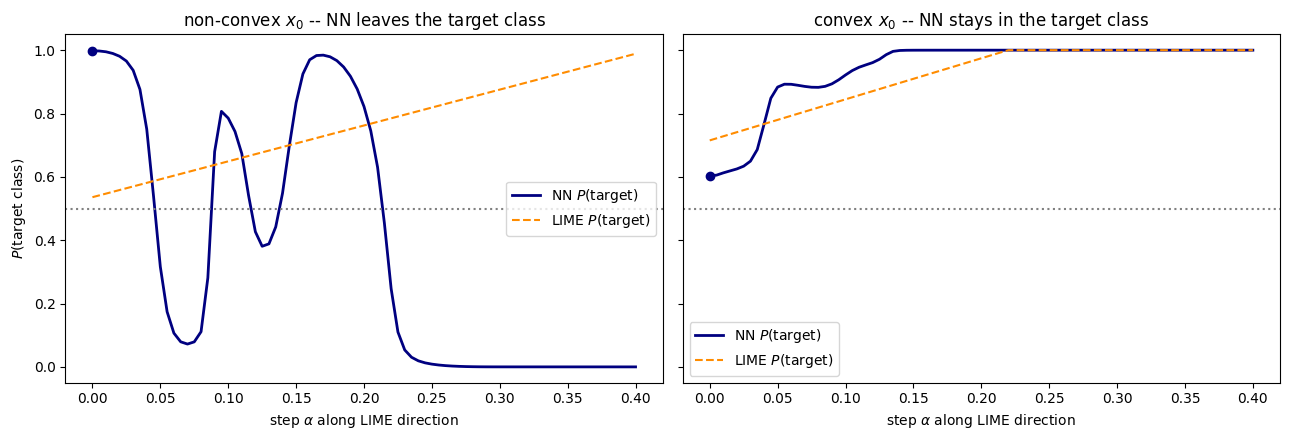

point         P(target) start  P(target) min   verdict
----------------------------------------------------------------
non-convex              0.998          0.000   LEAVES target (LIME wrong)
convex                  0.603          0.603   stays in target (LIME ok)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
panel_data = []
titles = ['non-convex $x_0$ -- NN leaves the target class',
          'convex $x_0$ -- NN stays in the target class']
for ax, idx, title in [(axes[0], nc_idx, titles[0]),
                       (axes[1], conv_idx, titles[1])]:
    if idx is None:
        ax.set_title(title + '  [no candidate]'); continue
    a, f_t, g_t, target, _, _ = push(X_test[idx])
    panel_data.append((title, target, f_t))
    ax.plot(a, f_t, color='navy', lw=2, label='NN $P(\mathrm{target})$')
    ax.plot(a, g_t, color='darkorange', lw=1.5, ls='--', label='LIME $P(\mathrm{target})$')
    ax.axhline(0.5, color='gray', ls=':')
    ax.scatter([0], [f_t[0]], color='navy', zorder=5)
    ax.set_xlabel(r'step $\alpha$ along LIME direction')
    ax.set_title(title); ax.legend(loc='best')
axes[0].set_ylabel('$P(\mathrm{target\ class})$')
plt.tight_layout(); plt.show()

print(f'{"point":12s} {"P(target) start":>16s} {"P(target) min":>14s}   verdict')
print('-' * 64)
for title, target, f_t in panel_data:
    verdict = 'LEAVES target (LIME wrong)' if f_t.min() < 0.5 else 'stays in target (LIME ok)'
    kind = 'non-convex' if 'non-convex' in title else 'convex'
    print(f'{kind:12s} {f_t[0]:>16.3f} {f_t.min():>14.3f}   {verdict}')
